In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')
%matplotlib inline

In [4]:
df = pd.read_csv('data/PRSA_data.csv') 
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [5]:
df['Datetime'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.sort_values("Datetime").reset_index(drop = True)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,Datetime
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


**Calendar Feature Engineering**

In [ ]:
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['quarter'] = df['Datetime'].dt.quarter
df['dayofyear'] = df['Datetime'].dt.dayofyear
df['is_weekend']=(df['dayofweek']>=5).astype(int)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,Datetime,dayofweek,quarter,dayofyear,is_weekend
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00,4,1,1,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00,4,1,1,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00,4,1,1,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00,4,1,1,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00,4,1,1,0


**Lag & Rolling-Mean Feature Engineering**

In [ ]:
df['lag_1'] = df['pm2.5'].shift(1)
df['lag_24'] = df['pm2.5'].shift(24)
df['roll_24']=df['pm2.5'].shift(1).rolling(window=24).mean()
df['roll_168']=df['pm2.5'].shift(1).rolling(window=168).mean()
df[['pm2.5','lag_1','lag_24','roll_24','roll_168']].head(10)

,pm2.5,lag_1,lag_24,roll_24,roll_168
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.dropna(subset=['pm2.5','lag_1','lag_24','roll_24','roll_168']).reset_index(drop=True)
df.head(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,...,Ir,Datetime,dayofweek,quarter,dayofyear,is_weekend,lag_1,lag_24,roll_24,roll_168
0,193,2010,1,9,0,165.0,-17,-13.0,1027.0,cv,...,0,2010-01-09 00:00:00,5,1,9,1,169.0,210.0,176.208333,85.744048
1,194,2010,1,9,1,159.0,-17,-13.0,1027.0,NW,...,0,2010-01-09 01:00:00,5,1,9,1,165.0,195.0,174.333333,85.958333
2,195,2010,1,9,2,167.0,-17,-14.0,1027.0,NW,...,0,2010-01-09 02:00:00,5,1,9,1,159.0,275.0,172.833333,86.023810
3,196,2010,1,9,3,196.0,-17,-15.0,1027.0,NW,...,0,2010-01-09 03:00:00,5,1,9,1,167.0,164.0,168.333333,86.071429
4,197,2010,1,9,4,169.0,-17,-13.0,1027.0,NW,...,0,2010-01-09 04:00:00,5,1,9,1,196.0,110.0,169.666667,86.160714
5,198,2010,1,9,5,155.0,-19,-16.0,1027.0,NW,...,0,2010-01-09 05:00:00,5,1,9,1,169.0,100.0,172.125000,86.345238
6,199,2010,1,9,6,119.0,-18,-15.0,1027.0,NW,...,0,2010-01-09 06:00:00,5,1,9,1,155.0,81.0,174.416667,86.619048
7,200,2010,1,9,7,106.0,-19,-15.0,1027.0,NW,...,0,2010-01-09 07:00:00,5,1,9,1,119.0,71.0,176.000000,86.702381
8,201,2010,1,9,8,93.0,-18,-14.0,1028.0,NW,...,0,2010-01-09 08:00:00,5,1,9,1,106.0,66.0,177.458333,86.595238
9,202,2010,1,9,9,84.0,-18,-9.0,1029.0,NE,...,0,2010-01-09 09:00:00,5,1,9,1,93.0,92.0,178.583333,86.434524


**One-Hot Encode Wind Direction**

In [ ]:
df = pd.get_dummies(df,columns=['cbwd'],prefix='wind',drop_first=True)


In [ ]:
wind_cols = [c for c in df.columns if c.startswith('wind')]
df[wind_cols] = df[wind_cols].astype(int)
df[wind_cols]        

,wind_NW,wind_SE,wind_cv
0,0,0,1
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
22909,1,0,0
22910,1,0,0
22911,1,0,0
22912,1,0,0


**Lag Feature Relationship with Target**

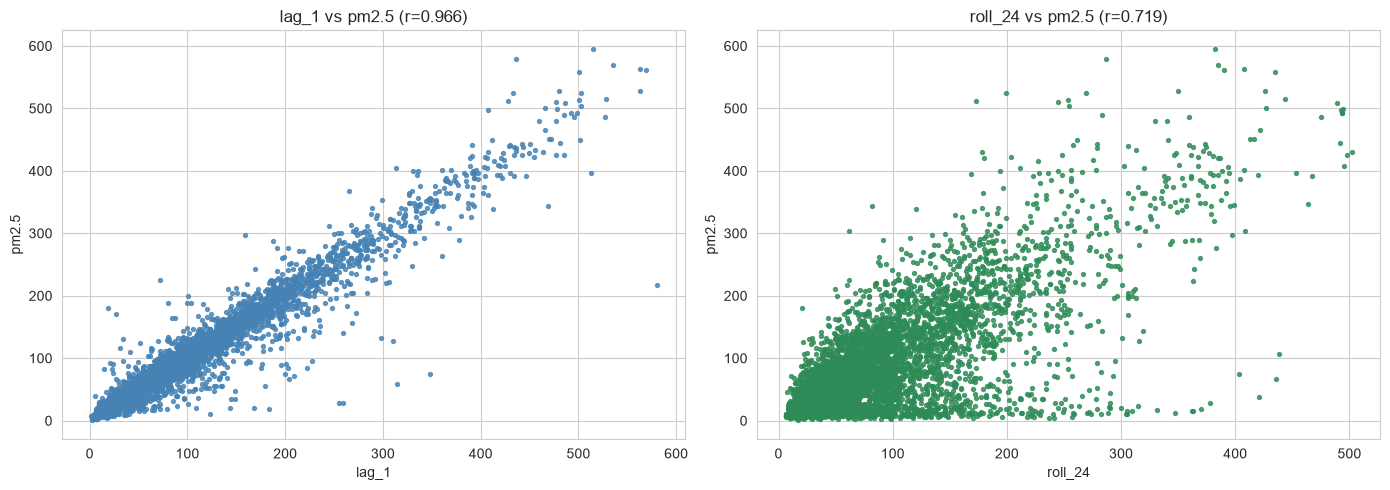

In [ ]:
sample = df.sample(5000,random_state=42)
fig,ax = plt.subplots(1,2,figsize=(14,5))
ax[0].scatter(sample['lag_1'],sample['pm2.5'],color='steelblue',s=8,alpha=0.8)
ax[0].set_xlabel('lag_1')
ax[0].set_ylabel('pm2.5')
ax[0].set_title(f"lag_1 vs pm2.5 (r={df[['lag_1','pm2.5']].corr().iloc[0,1]:.3f})")
ax[1].scatter(sample['roll_24'],sample['pm2.5'],color='seagreen',s=8,alpha=0.8)
ax[1].set_xlabel('roll_24')
ax[1].set_ylabel('pm2.5')
ax[1].set_title(f"roll_24 vs pm2.5 (r={df[['roll_24','pm2.5']].corr().iloc[0,1]:.3f})")
plt.tight_layout();plt.show()

<Axes: >

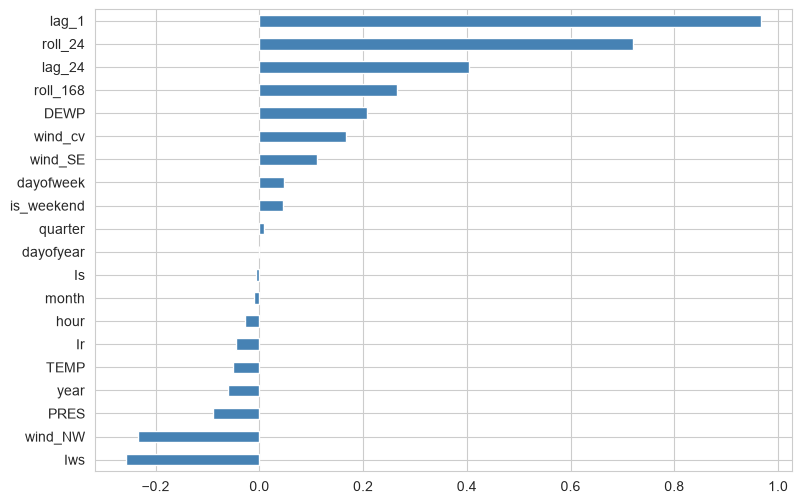

In [ ]:
df.columns
feature_cols = ['hour','dayofweek', 'month','quarter', 'year','dayofyear','is_weekend',
                'DEWP', 'TEMP', 'PRES','Iws', 'Is', 'Ir',  'lag_1', 'lag_24', 'roll_24', 'roll_168',
                'wind_NW','wind_SE', 'wind_cv']
corr_t = df[feature_cols+['pm2.5']].corr()['pm2.5'].drop('pm2.5').sort_values()
corr_t

plt.figure(figsize=(9,6))
corr_t.plot(kind='barh',color='steelblue')

**Save Cleaned Feature CSV**

In [ ]:
df.to_csv('data/air_quality_features.csv',index=False)